In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import Isomap
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
import urllib.request
import pandas as pd

The HR diagram (and the importance of data scaling in machine learning)

This assignment is about stars: we will work with a star catalogue of 240 stars described by the following information (these are features):

1. Temperature (in Kelvin)
2. Luminosity (L/Lo)
3. Radius (R/Ro)
4. Absolute magnitude (Mv)

We also have the following data for each star (these are like labels):

1. Color (Red/Orange/Yellow/White/Blue)
2. Spectral class ('A', 'B', 'F', 'G', 'K', 'M', 'O')
3. Star type (Brown dwarf/Red dwarf/White dwarf/Main sequence/Supergiant/Hypergiant)

In [2]:
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv")

('stars.csv', <http.client.HTTPMessage at 0x7e7572781f90>)

In [3]:
table_stars = pd.read_csv("stars.csv")

In [4]:
table_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,Brown Dwarf,Red,M
1,3042,0.000500,0.1542,16.60,Brown Dwarf,Red,M
2,2600,0.000300,0.1020,18.70,Brown Dwarf,Red,M
3,2800,0.000200,0.1600,16.65,Brown Dwarf,Red,M
4,1939,0.000138,0.1030,20.06,Brown Dwarf,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,Hypergiant,Blue,O
236,30839,834042.000000,1194.0000,-10.63,Hypergiant,Blue,O
237,8829,537493.000000,1423.0000,-10.73,Hypergiant,White,A
238,9235,404940.000000,1112.0000,-11.23,Hypergiant,White,A


To do list:

1. Apply PCA to the dataset at your disposal (hint: don't use columns with labels, only those with real numbers).
2. Project the dataset into the principal components, and do a scatter plot of the first two.

This will look terrible. Think about the units!
Explore what happens if you rescale the data first.
This is actually a very important lesson in machine learning: massaging your data before giving them to an algorithm can make things much much better.

You can try a linear, affine transformation such that each dimension goes between -1 and 1 or (which is the usual machine-learning approach) standardize your data such that each dimension has mean=0 and variance=1.
Redo your PCA. Should be much much better.

3. How much variance is explained by those two components?

In [5]:
# Assign unique integers from 0 to 6 to each star type
le = LabelEncoder()
table_stars['Star type'] = le.fit_transform(table_stars['Star type'])
labels = le.inverse_transform(table_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [6]:
table_stars

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


In [7]:
# remember sklearn requires format (n_samples, n_features)
x1 = table_stars["Temperature (K)"]
x2 = table_stars["Luminosity(L/Lo)"]
x3 = table_stars["Radius(R/Ro)"]
x4 = table_stars["Absolute magnitude(Mv)"]
y = table_stars["Star type"]
X = np.array([x1, x2, x3, x4]).T

In [8]:
X.shape

(240, 4)

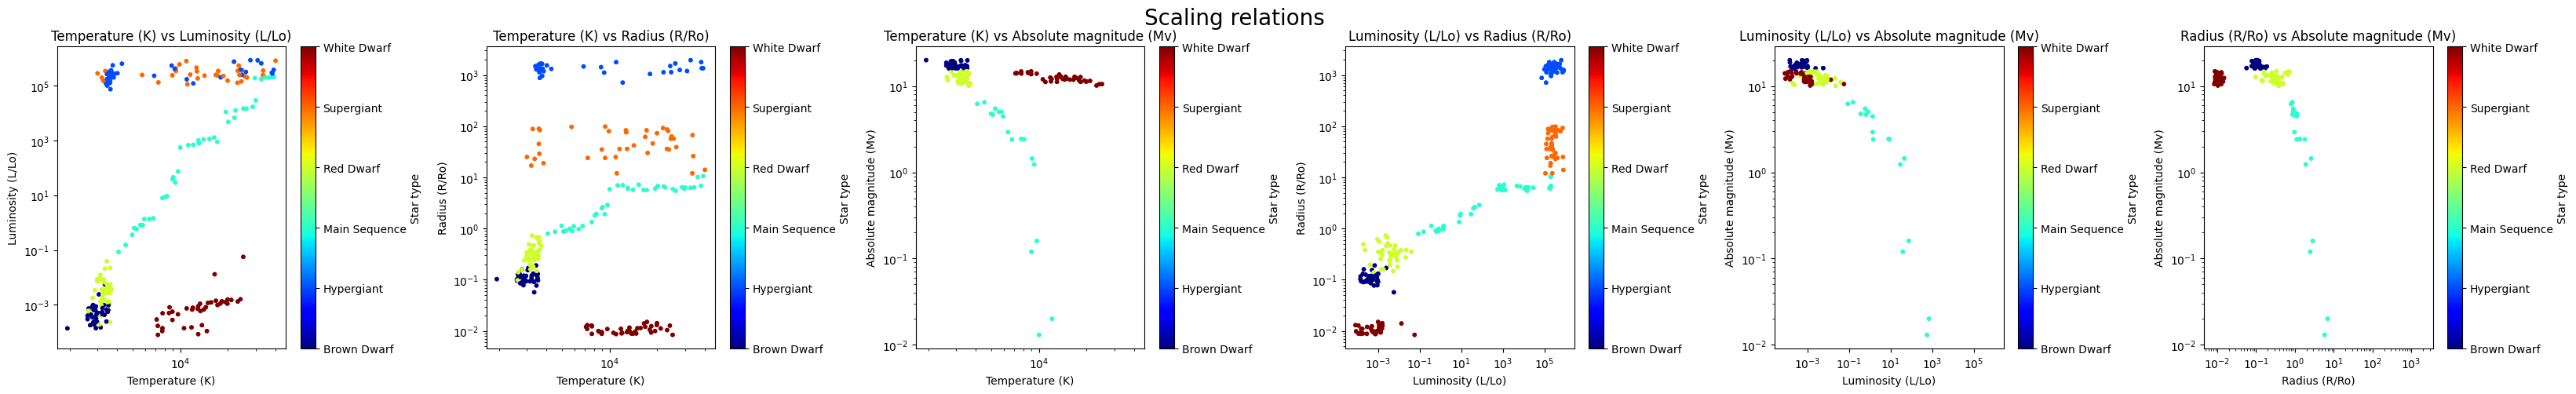

In [9]:
X_labels = ["Temperature (K)", "Luminosity (L/Lo)", "Radius (R/Ro)", "Absolute magnitude (Mv)"]
fig, axes = plt.subplots(1, 6, figsize=(40, 5))
fig.subplots_adjust(hspace=0.5, wspace=0.5)
fig.suptitle("Scaling relations", size=20)
count = 0
for i in range(4):
  for j in range(4):
    if j > i:
      axes[count].scatter(X[:, i], X[:, j], c=y, cmap='jet', marker=".")
      axes[count].set_xlabel(X_labels[i])
      axes[count].set_ylabel(X_labels[j])
      axes[count].set_title(X_labels[i]+" vs "+X_labels[j])
      axes[count].set_xscale('log')
      axes[count].set_yscale('log')
      cbar = fig.colorbar(axes[count].scatter(X[:, i], X[:, j], c=y, cmap='jet', marker="."), ax=axes[count])
      cbar.set_label('Star type')
      cbar.set_ticks(np.arange(0, 6, 1))
      cbar.set_ticklabels(class_names)
      count += 1

In [10]:
n = 2 # n_components can be optionally set
pca = PCA(n_components=n)
pca.fit(X)

X_pca = pca.transform(X)
mean = pca.mean_
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
evals = pca.explained_variance_ratio_

# Reconstruction of objects
X_reconstructed = mean + np.dot(X_pca, eigenvectors)

print("transformed dataset:", X_pca.shape)
print("eigenvalues:", eigenvalues.shape)
print("eigenvectors:", eigenvectors.shape)
print("mean:", mean.shape)
print("reconstructed dataset:", X_reconstructed.shape)


print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

transformed dataset: (240, 2)
eigenvalues: (2,)
eigenvectors: (2, 4)
mean: (4,)
reconstructed dataset: (240, 4)
Expained fractional variance of data encapsulated in the eigenvalues: [0.99760631 0.0023879 ]


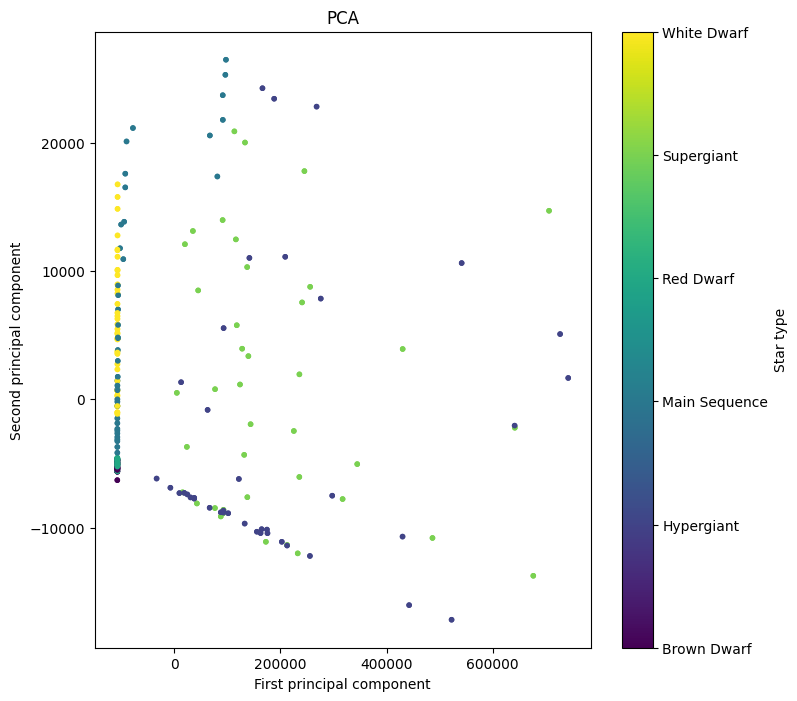

In [11]:
fig, axes = plt.subplots(figsize=(8, 8))
axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', marker=".")
axes.set_xlabel("First principal component")
axes.set_ylabel("Second principal component")
axes.set_title(f"PCA")
# axes.set_xscale('log')
# axes.set_yscale('log')
cbar = fig.colorbar(axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', marker="."), ax=axes)
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

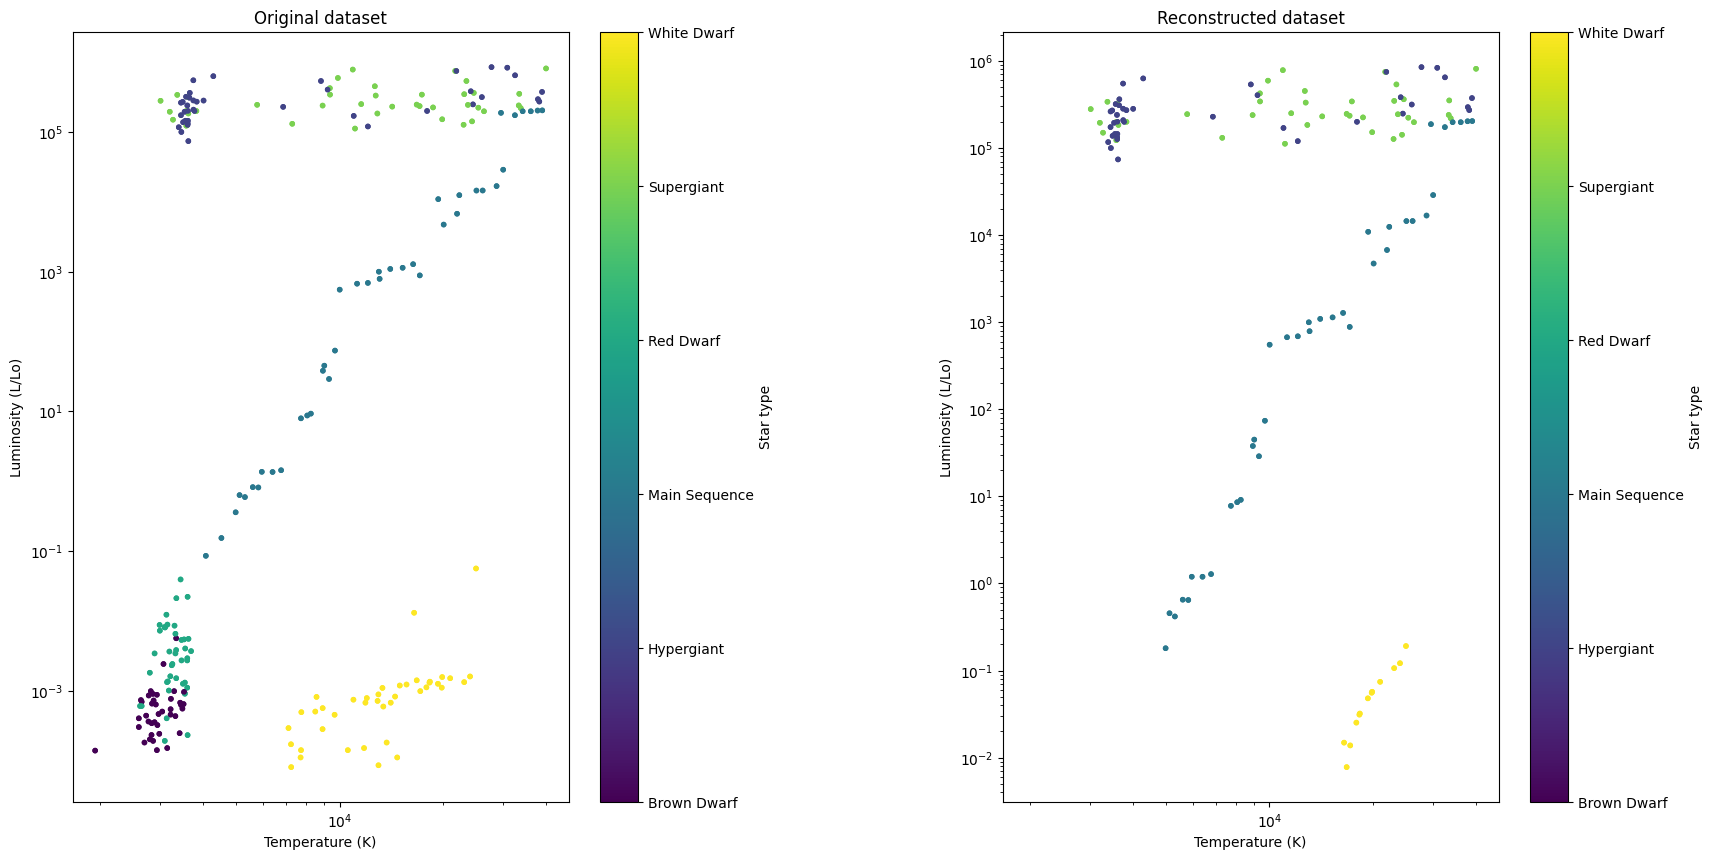

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)

axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker=".")
axes[0].set_xlabel(X_labels[0])
axes[0].set_ylabel(X_labels[1])
axes[0].set_title(f"Original dataset")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
cbar = fig.colorbar(axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker="."), ax=axes[0])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='viridis', marker=".")
axes[1].set_xlabel(X_labels[0])
axes[1].set_ylabel(X_labels[1])
axes[1].set_title(f"Reconstructed dataset")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
cbar = fig.colorbar(axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='viridis', marker="."), ax=axes[1])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

In [13]:
# standardize your data such that each dimension has mean=0 and variance=1.
# Then redo your PCA. Should be much much better.
std_scaler = StandardScaler()
X_std = std_scaler.fit_transform(X)

In [24]:
pca = PCA(n_components=0.95) # n_components estimated through an explained variance ratio imposition
pca.fit(X_std)

n = pca.n_components_
X_pca = pca.transform(X_std)
mean = pca.mean_
eigenvalues = pca.explained_variance_
eigenvectors = pca.components_
evals = pca.explained_variance_ratio_

# Reconstruction of objects
X_reconstructed = std_scaler.inverse_transform(mean + np.dot(X_pca, eigenvectors))

print("transformed dataset:", X_pca.shape)
print("eigenvalues:", eigenvalues.shape)
print("eigenvectors:", eigenvectors.shape)
print("mean:", mean.shape)
print("reconstructed dataset:", X_reconstructed.shape)

print('Expained fractional variance of data encapsulated in the eigenvalues: ' + str(evals))

transformed dataset: (240, 4)
eigenvalues: (4,)
eigenvectors: (4, 4)
mean: (4,)
reconstructed dataset: (240, 4)
Expained fractional variance of data encapsulated in the eigenvalues: [0.60357391 0.23500784 0.09329645 0.0681218 ]


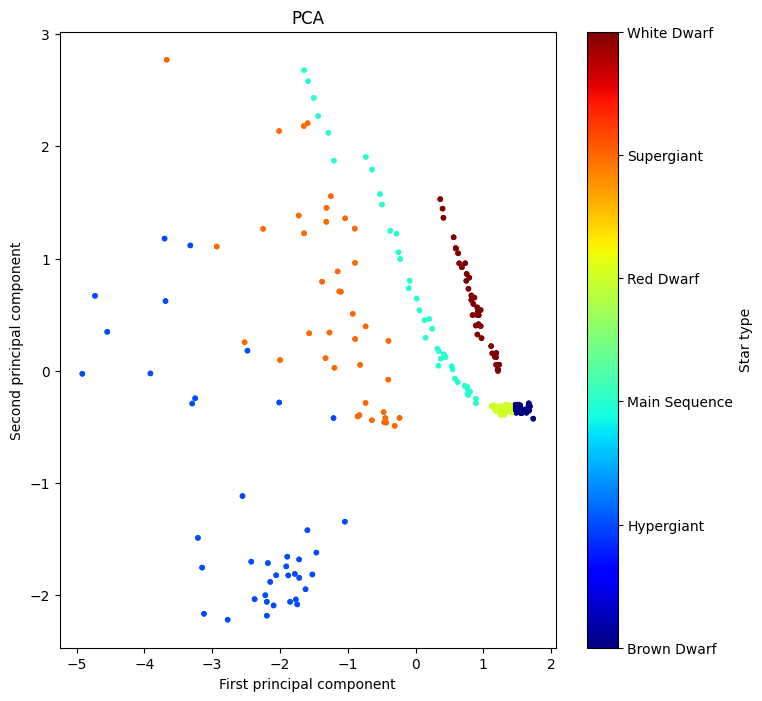

In [25]:
fig, axes = plt.subplots(figsize=(8, 8))
axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='jet', marker=".")
axes.set_xlabel("First principal component")
axes.set_ylabel("Second principal component")
axes.set_title(f"PCA")
cbar = fig.colorbar(axes.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='jet', marker="."), ax=axes)
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

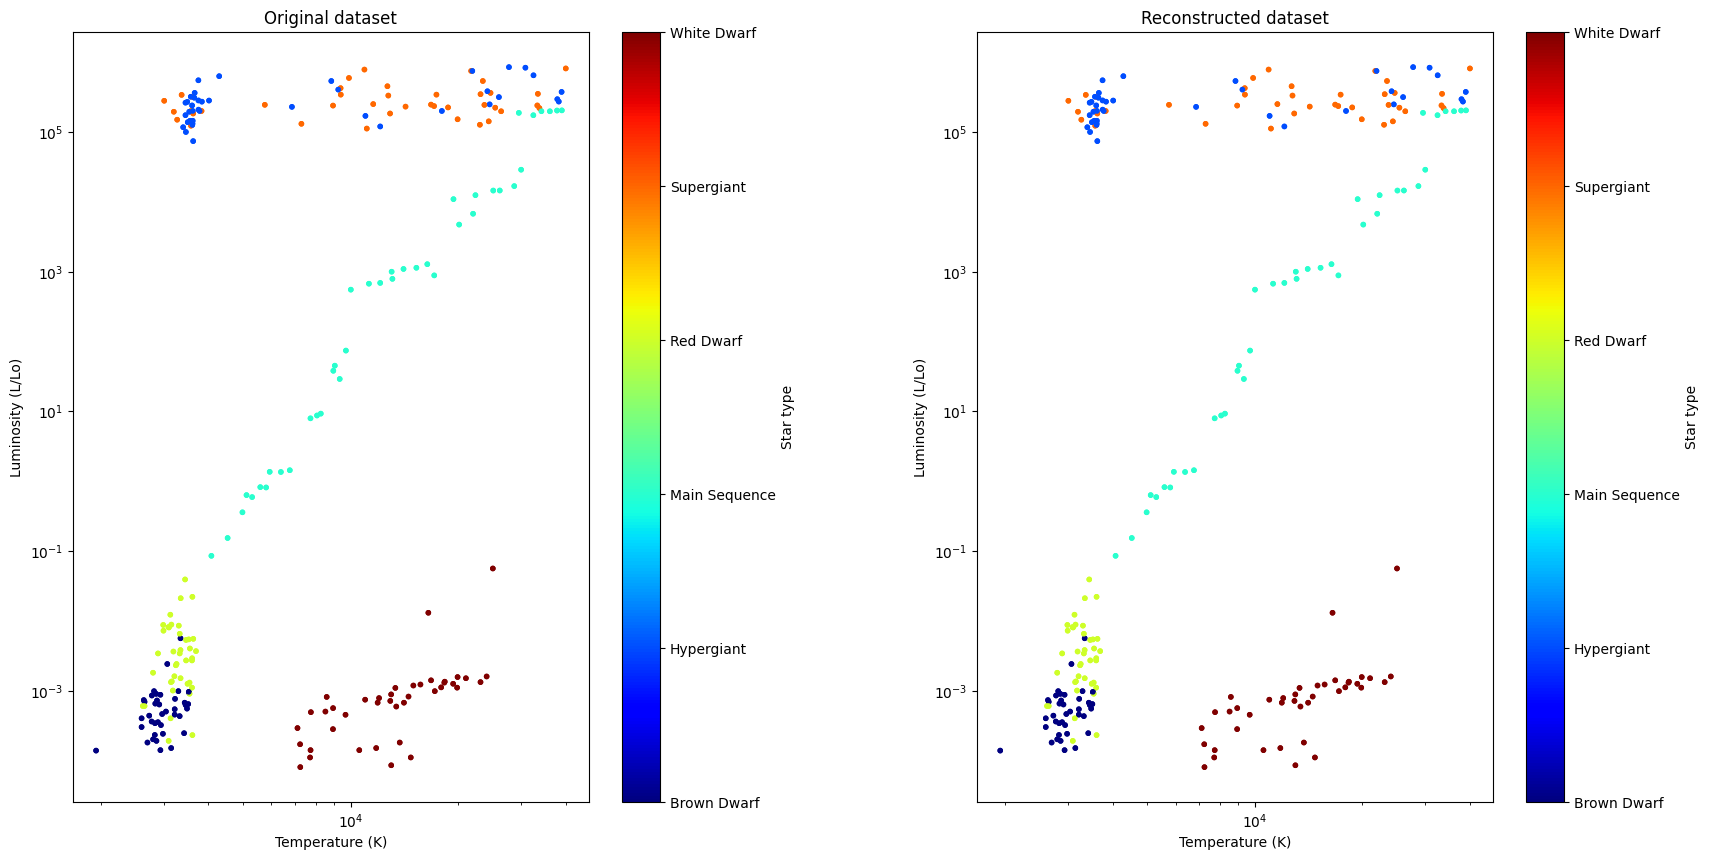

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='jet', marker=".")
axes[0].set_xlabel(X_labels[0])
axes[0].set_ylabel(X_labels[1])
axes[0].set_title(f"Original dataset")
axes[0].set_xscale('log')
axes[0].set_yscale('log')
cbar = fig.colorbar(axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='jet', marker="."), ax=axes[0])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='jet', marker=".")
axes[1].set_xlabel(X_labels[0])
axes[1].set_ylabel(X_labels[1])
axes[1].set_title(f"Reconstructed dataset")
axes[1].set_xscale('log')
axes[1].set_yscale('log')
cbar = fig.colorbar(axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], c=y, cmap='jet', marker="."), ax=axes[1])
cbar.set_label('Star type')
cbar.set_ticks(np.arange(0, 6, 1))
cbar.set_ticklabels(class_names)

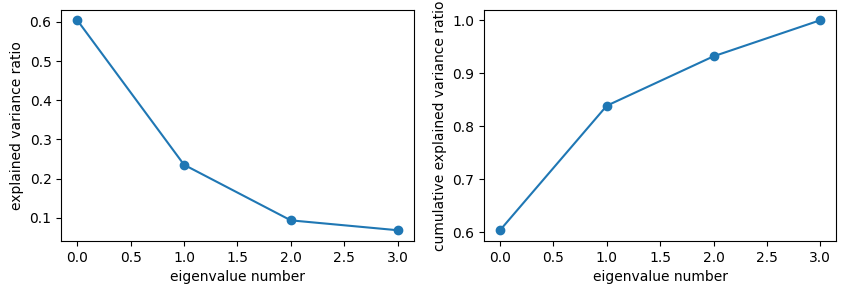

In [27]:
fig = plt.figure(figsize=(10, 3))

ax = fig.add_subplot(121)

ax.plot(np.arange(n), evals)
ax.scatter(np.arange(n), evals)

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("explained variance ratio")

ax = fig.add_subplot(122)

ax.plot(np.arange(n), evals.cumsum())
ax.scatter(np.arange(n), evals.cumsum())

ax.set_xlabel("eigenvalue number")
ax.set_ylabel("cumulative explained variance ratio")

plt.show()

In [28]:
print("The first component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[0]))
print("The second component explains {:.3f} of the variance in the data.".format(pca.explained_variance_ratio_[1]))
print("All components (n = {:.0f}) explain {:.3f} of the variance in the data.".format(n, sum(pca.explained_variance_ratio_)))

The first component explains 0.604 of the variance in the data.
The second component explains 0.235 of the variance in the data.
All components (n = 4) explain 1.000 of the variance in the data.
